Cell 1: Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

print("✅ Ready to analyze Twitter data!")
print("Let's see what the crypto community is talking about...")

✅ Ready to analyze Twitter data!
Let's see what the crypto community is talking about...


Cell 2: Load Twitter Dataset

In [2]:
# ==============================
# CELL 2: Load & Normalize Twitter JSON
# ==============================

import pandas as pd
from IPython.display import display

# Load JSON
df_twitter = pd.read_json('v4_x_tweets.json')

print(f"🐦 Loaded {len(df_twitter):,} tweets!")

# -------- Normalize public_metrics --------
if 'public_metrics' in df_twitter.columns:
    metrics_df = pd.json_normalize(df_twitter['public_metrics'])
    metrics_df = metrics_df.add_prefix('metric_')

    df_twitter = pd.concat(
        [df_twitter.drop(columns=['public_metrics']), metrics_df],
        axis=1
    )

# ---------- Pretty summary ----------
print("\n📊 DATASET OVERVIEW")
print("=" * 60)

print(f"Total rows   : {df_twitter.shape[0]:,}")
print(f"Total columns: {df_twitter.shape[1]}")

print("\n📌 Main Columns:")
main_cols = [
    'tokenSymbol', 'text', 'created_at', 'username'
]
for c in main_cols:
    if c in df_twitter.columns:
        print(f"  ✅ {c}")

print("\n📈 Engagement Metrics:")
metric_cols = [c for c in df_twitter.columns if c.startswith('metric_')]
for c in metric_cols:
    print(f"  🔹 {c}")

print("\n📱 Sample Tweets (first 3 rows):")
display(df_twitter[['tokenSymbol', 'username', 'text']].head(3))

🐦 Loaded 3,918 tweets!

📊 DATASET OVERVIEW
Total rows   : 3,918
Total columns: 35

📌 Main Columns:
  ✅ tokenSymbol
  ✅ text
  ✅ created_at
  ✅ username

📈 Engagement Metrics:
  🔹 metric_retweet_count
  🔹 metric_reply_count
  🔹 metric_like_count
  🔹 metric_quote_count
  🔹 metric_bookmark_count
  🔹 metric_impression_count

📱 Sample Tweets (first 3 rows):


,tokenSymbol,username,text
0,DAI,ChartPatternAi,💧 Stablecoin Liquidity Pulse\nTotal (USDT+USDC...
1,DAI,Ousmane79385781,"https://t.co/HTjI1Jo7Oi\nToday, your wallet ad..."
2,DAI,StageChronicles,Breaking: Explosive demand sparks 1M DAI token...


Cell 3: What Information Do We Have?

In [3]:
# ==============================
# CELL 3: What Information Do We Have?
# ==============================

important_columns = [
    ('tokenSymbol', 'Crypto token'),
    ('text', 'Tweet content'),
    ('metric_like_count', 'Likes'),
    ('metric_retweet_count', 'Retweets'),
    ('metric_impression_count', 'Impressions'),
]

print("📋 Available Information in Each Tweet")
print("-" * 40)

for col, desc in important_columns:
    status = "✅" if col in df_twitter.columns else "❌"
    print(f"{status} {col:<25} — {desc}")

# ------------------------------
# Sample tweet preview
# ------------------------------
print("\n📱 Sample Tweet Preview")
print("-" * 40)

if 'text' in df_twitter.columns and 'tokenSymbol' in df_twitter.columns:
    sample = df_twitter[df_twitter['text'].notna()].iloc[0]

    print(f"🔹 Token   : {sample['tokenSymbol']}")
    print(f"🔹 Content : {sample['text'][:150]}{'...' if len(sample['text']) > 150 else ''}")
else:
    print("⚠️ Required columns not found to display a sample tweet.")

📋 Available Information in Each Tweet
----------------------------------------
✅ tokenSymbol               — Crypto token
✅ text                      — Tweet content
✅ metric_like_count         — Likes
✅ metric_retweet_count      — Retweets
✅ metric_impression_count   — Impressions

📱 Sample Tweet Preview
----------------------------------------
🔹 Token   : DAI
🔹 Content : 💧 Stablecoin Liquidity Pulse
Total (USDT+USDC+DAI): $264.07B
7d Change: ↗️ $1.93B (+0.74%)

USDT: $182.96B (+0.72%)
USDC: $76.42B (+0.68%)
DAI: $4.69B...


Cell 4: 🔥 Most Tweeted Currencies

🏆 TOP 10 MOST TWEETED CRYPTO TOKENS
 1. USDT       - 213 tweets
 2. YUSD       - 201 tweets
 3. EURA       - 200 tweets
 4. USDN       - 199 tweets
 5. RLUSD      - 198 tweets
 6. USDS       - 193 tweets
 7. USDG       - 190 tweets
 8. MIM        - 188 tweets
 9. PAXG       - 184 tweets
10. DAI        - 172 tweets


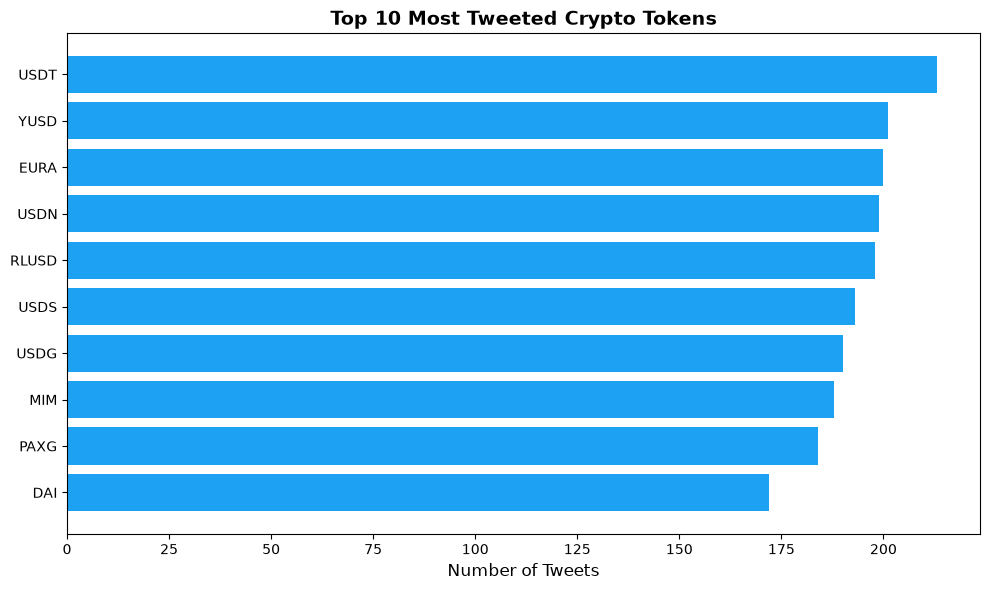


🔥 Champion: USDT with 213 tweets!


In [4]:
tweet_counts = df_twitter['tokenSymbol'].value_counts().head(10)

print("🏆 TOP 10 MOST TWEETED CRYPTO TOKENS")
print("=" * 50)

for rank, (crypto, count) in enumerate(tweet_counts.items(), 1):
    print(f"{rank:2d}. {crypto:10s} - {count:3d} tweets")

print("=" * 50)

plt.figure(figsize=(10, 6))
plt.barh(tweet_counts.index, tweet_counts.values, color='#1DA1F2')
plt.xlabel('Number of Tweets', fontsize=12)
plt.title('Top 10 Most Tweeted Crypto Tokens', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n🔥 Champion: {tweet_counts.index[0]} with {tweet_counts.values[0]} tweets!")

Cell 5: 💙 Count Total Likes

❤️ TOP 10 CURRENCIES BY TOTAL LIKES
 1. RLUSD      - 14,278 likes
 2. BFUSD      - 6,512 likes
 3. YUSD       - 2,388 likes
 4. USDC       - 2,376 likes
 5. USDN       - 2,124 likes
 6. USDE       - 2,022 likes
 7. USDY       - 1,655 likes
 8. USDG       - 1,394 likes
 9. PYUSD      - 1,116 likes
10. USDT       - 1,061 likes


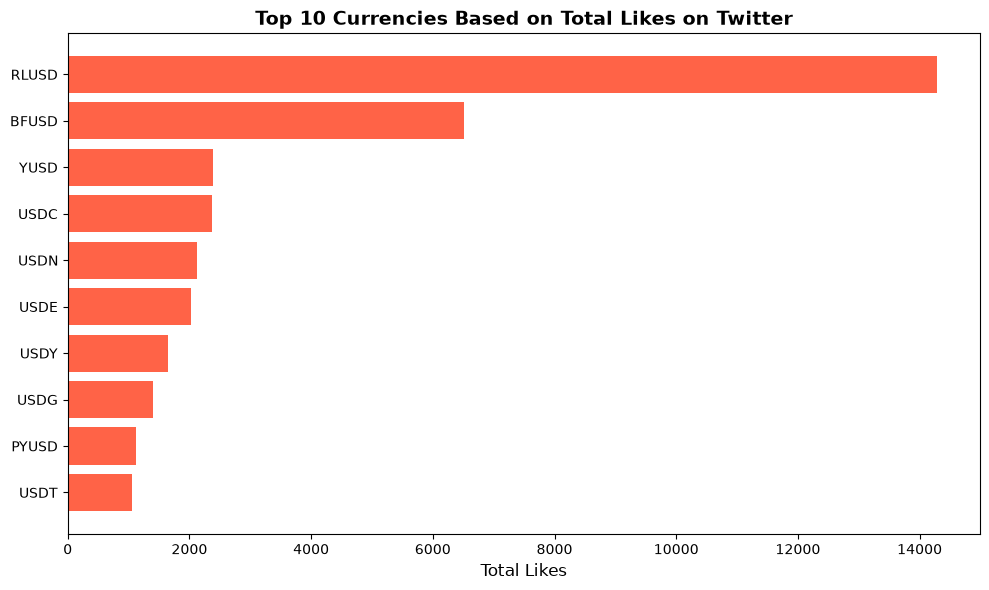


💙 Most liked: RLUSD (14,278 likes)


In [5]:
# ==============================
# CELL 5: 💙 Count Total Likes
# ==============================

import matplotlib.pyplot as plt
from IPython.display import display

likes_column = 'metric_like_count'

# Check if the "like" column exists
if likes_column not in df_twitter.columns:
    print("❌ The like_count column was not found in the data.")
else:
    # Switch to numeric to be sure.
    df_twitter[likes_column] = pd.to_numeric(
        df_twitter[likes_column],
        errors='coerce'
    ).fillna(0)

    # Groups are grouped by token symbol and the total number of likes is calculated.
    total_likes = (
        df_twitter
        .groupby('tokenSymbol')[likes_column]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    print("❤️ TOP 10 CURRENCIES BY TOTAL LIKES")
    print("=" * 55)

    for rank, (symbol, likes) in enumerate(total_likes.items(), 1):
        print(f"{rank:2d}. {symbol:10s} - {int(likes):,} likes")

    print("=" * 55)

    # ----- Draw a graph. -----
    plt.figure(figsize=(10, 6))
    plt.barh(
        total_likes.index,
        total_likes.values,
        color='tomato'
    )
    plt.xlabel('Total Likes', fontsize=12)
    plt.title(
        'Top 10 Currencies Based on Total Likes on Twitter',
        fontsize=14,
        fontweight='bold'
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(
        f"\n💙 Most liked: "
        f"{total_likes.index[0]} "
        f"({int(total_likes.values[0]):,} likes)"
    )

Cell 6: 🔄 Count Total Retweets

🔄 TOP 10 CRYPTO TOKENS BY TOTAL RETWEETS
 1. RLUSD      - 3,862 retweets
 2. BFUSD      - 1,183 retweets
 3. YUSD       - 524 retweets
 4. USDD       - 357 retweets
 5. USDY       - 272 retweets
 6. GHO        - 258 retweets
 7. USDC       - 250 retweets
 8. USDG       - 185 retweets
 9. USDE       - 181 retweets
10. USDT       - 174 retweets


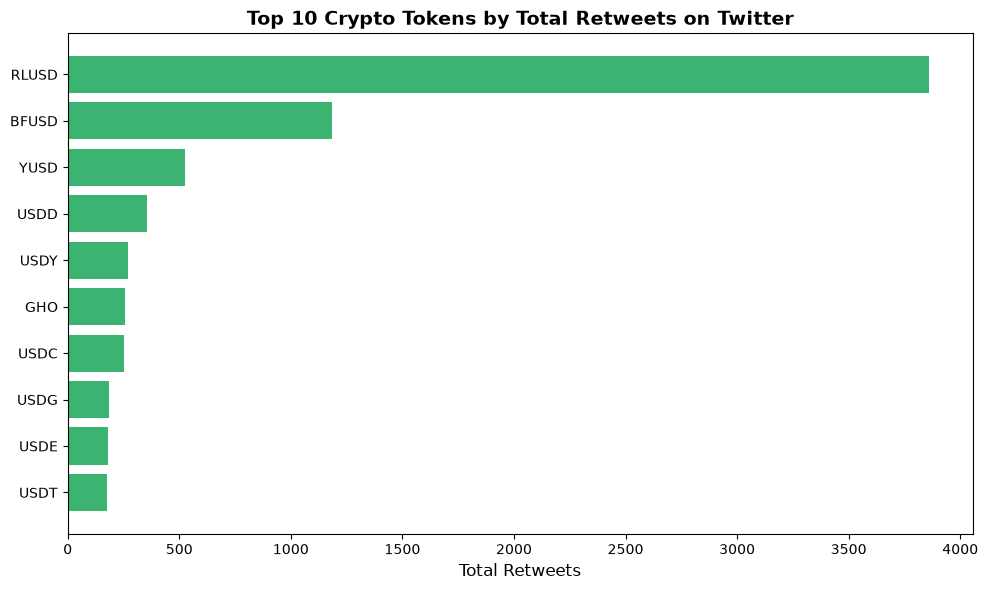


🔄 Most retweeted token: RLUSD (3,862 retweets)


In [6]:
# ==============================
# CELL 6: 🔄 Count Total Retweets
# ==============================

import matplotlib.pyplot as plt

retweets_column = 'metric_retweet_count'

# Check if the retweet column exists
if retweets_column not in df_twitter.columns:
    print("❌ Retweet count column not found in the dataset")
else:
    # Convert to numeric for safety
    df_twitter[retweets_column] = pd.to_numeric(
        df_twitter[retweets_column],
        errors='coerce'
    ).fillna(0)

    # Group by tokenSymbol and calculate total retweets
    total_retweets = (
        df_twitter
        .groupby('tokenSymbol')[retweets_column]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    print("🔄 TOP 10 CRYPTO TOKENS BY TOTAL RETWEETS")
    print("=" * 55)

    for rank, (symbol, retweets) in enumerate(total_retweets.items(), 1):
        print(f"{rank:2d}. {symbol:10s} - {int(retweets):,} retweets")

    print("=" * 55)

    # ----- Plot -----
    plt.figure(figsize=(10, 6))
    plt.barh(
        total_retweets.index,
        total_retweets.values,
        color='mediumseagreen'
    )
    plt.xlabel('Total Retweets', fontsize=12)
    plt.title(
        'Top 10 Crypto Tokens by Total Retweets on Twitter',
        fontsize=14,
        fontweight='bold'
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(
        f"\n🔄 Most retweeted token: "
        f"{total_retweets.index[0]} "
        f"({int(total_retweets.values[0]):,} retweets)"
    )


Cell 7: 👁️ Engagement Score

🏆 TOP 10 CRYPTO TOKENS BY ENGAGEMENT SCORE
(Engagement = Likes + Retweets × 2)

 1. RLUSD      - 22,002 points
 2. BFUSD      - 8,878 points
 3. YUSD       - 3,436 points
 4. USDC       - 2,876 points
 5. USDE       - 2,384 points
 6. USDN       - 2,318 points
 7. USDY       - 2,199 points
 8. USDG       - 1,764 points
 9. USDD       - 1,448 points
10. USDT       - 1,409 points


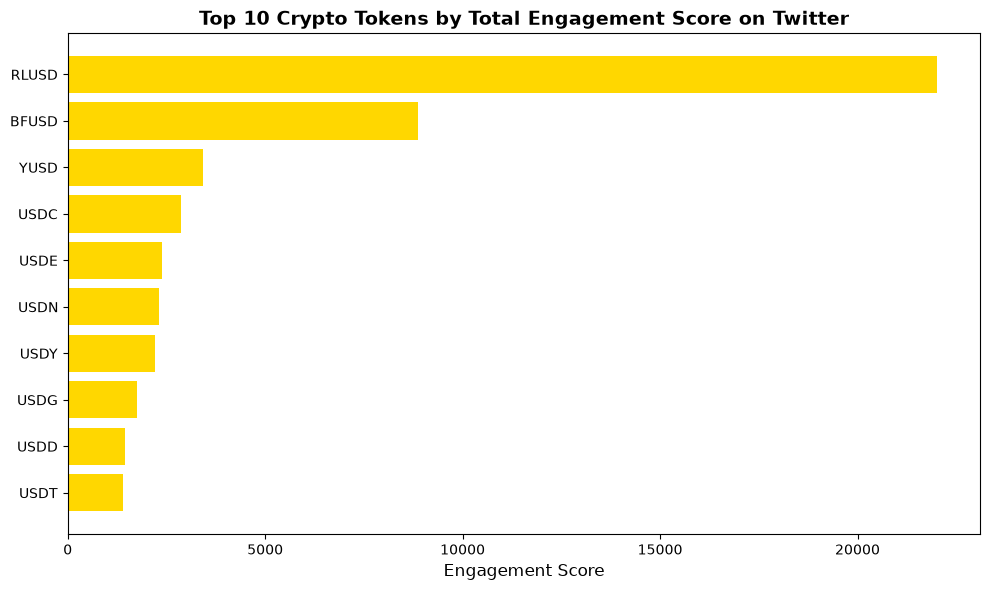


🎉 MOST ENGAGING TOKEN: RLUSD (22,002 points)


In [7]:
# ==============================
# CELL 7: 👁️ Engagement Score
# ==============================

import matplotlib.pyplot as plt

likes_column = 'metric_like_count'
retweets_column = 'metric_retweet_count'

# Check required columns
missing_cols = [
    col for col in [likes_column, retweets_column]
    if col not in df_twitter.columns
]

if missing_cols:
    print(f"❌ Missing required columns to calculate engagement: {missing_cols}")
else:
    # Convert to numeric for safety
    df_twitter[likes_column] = pd.to_numeric(
        df_twitter[likes_column], errors='coerce'
    ).fillna(0)

    df_twitter[retweets_column] = pd.to_numeric(
        df_twitter[retweets_column], errors='coerce'
    ).fillna(0)

    # --------------------------
    # Calculate Engagement Score
    # Score = Likes + (Retweets × 2)
    # --------------------------
    df_twitter['engagement_score'] = (
        df_twitter[likes_column] +
        df_twitter[retweets_column] * 2
    )

    # Total engagement by token
    engagement = (
        df_twitter
        .groupby('tokenSymbol')['engagement_score']
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    print("🏆 TOP 10 CRYPTO TOKENS BY ENGAGEMENT SCORE")
    print("=" * 60)
    print("(Engagement = Likes + Retweets × 2)\n")

    for rank, (symbol, score) in enumerate(engagement.items(), 1):
        print(f"{rank:2d}. {symbol:10s} - {int(score):,} points")

    print("=" * 60)

    # ----- Plot -----
    plt.figure(figsize=(10, 6))
    plt.barh(
        engagement.index,
        engagement.values,
        color='gold'
    )
    plt.xlabel('Engagement Score', fontsize=12)
    plt.title(
        'Top 10 Crypto Tokens by Total Engagement Score on Twitter',
        fontsize=14,
        fontweight='bold'
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(
        f"\n🎉 MOST ENGAGING TOKEN: "
        f"{engagement.index[0]} "
        f"({int(engagement.values[0]):,} points)"
    )


Cell 8: 📊 Summary Statistics

In [8]:
# ==============================
# CELL 8: 📊 Summary Statistics
# ==============================

likes_column = 'metric_like_count'
retweets_column = 'metric_retweet_count'

print("📊 TWITTER DATA SUMMARY")
print("=" * 65)

# Total number of tweets
total_tweets = len(df_twitter)
print(f"🐦 Total tweets analyzed            : {total_tweets:,}")

# Number of unique tokens
unique_tokens = df_twitter['tokenSymbol'].nunique()
print(f"🪙 Unique crypto tokens mentioned   : {unique_tokens}")

# Total likes
if likes_column in df_twitter.columns:
    total_likes_all = pd.to_numeric(
        df_twitter[likes_column], errors='coerce'
    ).fillna(0).sum()
    print(f"❤️ Total likes                      : {int(total_likes_all):,}")

# Total retweets
if retweets_column in df_twitter.columns:
    total_retweets_all = pd.to_numeric(
        df_twitter[retweets_column], errors='coerce'
    ).fillna(0).sum()
    print(f"🔄 Total retweets                   : {int(total_retweets_all):,}")

# Average likes per tweet
if likes_column in df_twitter.columns:
    avg_likes = pd.to_numeric(
        df_twitter[likes_column], errors='coerce'
    ).fillna(0).mean()
    print(f"💙 Average likes per tweet          : {avg_likes:.2f}")

# Average retweets per tweet
if retweets_column in df_twitter.columns:
    avg_retweets = pd.to_numeric(
        df_twitter[retweets_column], errors='coerce'
    ).fillna(0).mean()
    print(f"🔁 Average retweets per tweet       : {avg_retweets:.2f}")

print("=" * 65)

print("\n✨ QUICK INSIGHTS:")

if 'tweet_counts' in globals():
    print(f"  🥇 Most tweeted token             : {tweet_counts.index[0]}")

if 'total_likes' in globals():
    print(f"  ❤️ Most liked token               : {total_likes.index[0]}")

if 'total_retweets' in globals():
    print(f"  🔄 Most retweeted token           : {total_retweets.index[0]}")

if 'engagement' in globals():
    print(f"  🏆 Highest engagement token       : {engagement.index[0]}")

📊 TWITTER DATA SUMMARY
🐦 Total tweets analyzed            : 3,918
🪙 Unique crypto tokens mentioned   : 63
❤️ Total likes                      : 46,900
🔄 Total retweets                   : 9,134
💙 Average likes per tweet          : 11.97
🔁 Average retweets per tweet       : 2.33

✨ QUICK INSIGHTS:
  🥇 Most tweeted token             : USDT
  ❤️ Most liked token               : RLUSD
  🔄 Most retweeted token           : RLUSD
  🏆 Highest engagement token       : RLUSD


Cell 9: 🎯 Your Achievement Summary

In [9]:
# ==============================
# CELL 9: 🎯 Task Completion Summary
# ==============================

print("=" * 70)
print("🎉 CONGRATULATIONS! YOU HAVE COMPLETED TASK 2 – TWITTER BUZZ ANALYSIS")
print("=" * 70)
print()

print("In this task, you have:")
print("  ✅ Analyzed real Twitter (X) tweet data")
print("  ✅ Processed JSON data and normalized public_metrics")
print("  ✅ Identified the most mentioned crypto tokens")
print("  ✅ Calculated total Likes and Retweets per token")
print("  ✅ Built an Engagement Score (Likes + Retweets × 2)")
print("  ✅ Visualized insights using charts")

print()
print("📌 KEY CONCLUSIONS:")
if 'engagement' in globals():
    print(f"  🏆 Token with the highest Twitter engagement: {engagement.index[0]}")
if 'tweet_counts' in globals():
    print(f"  🥇 Most mentioned token on Twitter: {tweet_counts.index[0]}")

print()
print("🚀 NEXT TASK: TASK 3 – REDDIT DISCUSSION ANALYSIS")
print("You will continue by analyzing:")
print("  - Reddit posts")
print("  - Upvotes & comments")
print("  - Comparison between Twitter and Reddit")

print()
print("=" * 70)
print("✨ Great work! You are ready to move on to the next task.")
print("=" * 70)

🎉 CONGRATULATIONS! YOU HAVE COMPLETED TASK 2 – TWITTER BUZZ ANALYSIS

In this task, you have:
  ✅ Analyzed real Twitter (X) tweet data
  ✅ Processed JSON data and normalized public_metrics
  ✅ Identified the most mentioned crypto tokens
  ✅ Calculated total Likes and Retweets per token
  ✅ Built an Engagement Score (Likes + Retweets × 2)
  ✅ Visualized insights using charts

📌 KEY CONCLUSIONS:
  🏆 Token with the highest Twitter engagement: RLUSD
  🥇 Most mentioned token on Twitter: USDT

🚀 NEXT TASK: TASK 3 – REDDIT DISCUSSION ANALYSIS
You will continue by analyzing:
  - Reddit posts
  - Upvotes & comments
  - Comparison between Twitter and Reddit

✨ Great work! You are ready to move on to the next task.
